# Stage 3, Track B — Feature-Based Cetacean Classifier

No deep learning, no Stage 2 reuse - mirrors Track A's strategy: measure a handful of numbers
from each annotated region (box aspect ratio, size, brightness/colour vs. surrounding water),
classify with logistic regression.

**Format confirmed:** YOLO `.txt`, one file per image, single class (id 0).

**Critical finding from a 7-image sample:** 2 of 7 images were duplicates or rotated copies of
other images in the same sample (identical box dimensions, only position differed). This notebook
treats duplicate detection as a first-class step, not an afterthought - train/eval splitting
happens by duplicate GROUP, never by individual file.

---

### What changed in v6

1. **Group-aware cross-validation (cell 8).** Folds are now built so copies of the same photo can never sit on both
   sides of a fold. Before, they could, which made the cross-validation scores optimistic. The held-out eval was
   already split by group and is unaffected. **Expect the cross-validation numbers to be equal to or lower than before.**
2. **Letterbox bars (cells 4, 5, 6).** Black side/top bars are detected per image. Negative patches are sampled only
   inside the picture area, the surrounding ring is limited to it, and near-black pixels are ignored in the statistics.
   `relative_area` is now measured against the picture area, not the padded canvas.
3. **Negative sizes (cell 5).** Images with no annotated box used to get one fixed patch size (10% x 10% of the
   image). They now draw sizes from the real box-size distribution, and each patch uses one real (width, height) pair.

Because the data changes, **re-run from cell 1**. Cell 6 converts each image to LAB colour once instead of once per box,
which offsets the cost of the new bar detection, so run time should be similar to before or shorter.

4. **Rotation-aware duplicate grouping (cell 3).** Found while testing v6: two sample files were the same photo
   rotated 90 degrees, but the old fingerprint put them in different groups, so a rotated twin could land in train
   while its original sat in eval. Sorting width/height within each box fixes this for 90-degree rotations. It does
   not catch copies that were cropped or rescaled, so the group count is still an upper bound on independent photos.
   **Your earlier held-out numbers may have been slightly optimistic because of this.**


In [1]:
# --- Cell 1: Config ---
from pathlib import Path
import random

random.seed(42)

CETACEAN_IMAGES_DIR = Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Stage3_TrackB\train\images")        # UPDATE THIS - folder of .jpg/.png files
CETACEAN_ANNOTATIONS_DIR = Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Stage3_TrackB\train\labels")  # UPDATE THIS - folder of matching .txt files
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

RING_PAD_FRAC = 0.5       # ring width around each box, as a fraction of the box's own size
N_NEGATIVES_PER_IMAGE = 2  # how many empty regions to sample per image as negative examples
N_EVAL_GROUPS_TARGET = 0.2 # roughly 20% of duplicate-groups held out for eval

# --- v6 additions ---
BAR_MEAN_THRESH = 10   # a column/row whose brightest-channel average is below this counts as a black letterbox bar
MIN_BAR_PX = 8         # ignore dark edges thinner than this (compression artefacts, not real bars)
BAR_MARGIN_PX = 2      # trim this many extra pixels inside a detected bar edge
BLACK_L_THRESH = 8     # pixels darker than this (LAB lightness, 0-255) are treated as padding and ignored
CV_FOLDS = 5           # cross-validation folds (built so no photo group is ever split across folds)

print("Config set.")

Config set.


In [2]:
# --- Cell 2: Load every image + its YOLO annotation ---

def load_yolo_boxes(txt_path, img_w, img_h):
    """Returns a list of (class_id, x0, y0, x1, y1) in PIXEL coordinates."""
    boxes = []
    if not txt_path.exists():
        return boxes
    for line in txt_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls_id, xc, yc, w, h = int(parts[0]), *map(float, parts[1:5])
        bw, bh = w * img_w, h * img_h
        x0, y0 = (xc * img_w) - bw / 2, (yc * img_h) - bh / 2
        boxes.append((cls_id, x0, y0, x0 + bw, y0 + bh))
    return boxes

from PIL import Image

image_paths = sorted(p for p in CETACEAN_IMAGES_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
annotation_paths_by_stem = {p.stem: p for p in CETACEAN_ANNOTATIONS_DIR.rglob("*.txt")}
print(f"Found {len(annotation_paths_by_stem)} annotation files in {CETACEAN_ANNOTATIONS_DIR}")
print(f"Found {len(image_paths)} images")

records = []
n_empty = 0
for img_path in image_paths:
    txt_path = annotation_paths_by_stem.get(img_path.stem)
    if txt_path is None:
        n_empty += 1
        records.append({"path": img_path, "img_w": img_w, "img_h": img_h, "boxes": []})
        continue
    with Image.open(img_path) as im:
        img_w, img_h = im.size
    boxes = load_yolo_boxes(txt_path, img_w, img_h)
    if not boxes:
        n_empty += 1
    records.append({"path": img_path, "img_w": img_w, "img_h": img_h, "boxes": boxes})

print(f"Images with at least one box: {len(records) - n_empty}")
n_missing_file = sum(1 for r in records if r["path"].stem not in annotation_paths_by_stem)
print(f"Images with ZERO boxes: {n_empty} total "
      f"({n_missing_file} had no matching .txt file at all, "
      f"{n_empty - n_missing_file} had a .txt file that was empty)")

Found 7460 annotation files in C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Stage3_TrackB\train\labels
Found 7460 images
Images with at least one box: 5632
Images with ZERO boxes: 1828 total (0 had no matching .txt file at all, 1828 had a .txt file that was empty)


In [3]:
# --- Cell 3: Detect duplicate / rotated / flipped source photos ---
# Rotation and flipping preserve each box"s (width, height) exactly - only position changes.
# Two images sharing the same SET of box dimensions are almost certainly the same source photo.
# This is the safeguard from the 7-image sample finding: 2 of 7 were duplicates of each other.

def box_dims_fingerprint(record, decimals=3):
    # v6: width and height are sorted WITHIN each box, so a 90-degree rotation (which swaps width and
    # height) gives the same fingerprint. Before, only copies with identical (width, height) order matched.
    dims = sorted(
        tuple(sorted((round(x1 - x0, decimals), round(y1 - y0, decimals))))
        for _, x0, y0, x1, y1 in record["boxes"]
    )
    return tuple(dims)

groups = {}   # fingerprint -> list of record indices
for i, r in enumerate(records):
    if not r["boxes"]:
        continue   # unboxed images have no fingerprint to group by - handled separately
    fp = box_dims_fingerprint(r)
    groups.setdefault(fp, []).append(i)

dup_groups = {fp: idxs for fp, idxs in groups.items() if len(idxs) > 1}
n_in_dup_groups = sum(len(idxs) for idxs in dup_groups.values())

print(f"Distinct box-dimension fingerprints (boxed images only): {len(groups)}")
print(f"Fingerprints shared by more than one image (duplicate/rotated groups): {len(dup_groups)}")
print(f"Images involved in a duplicate group: {n_in_dup_groups} of {sum(1 for r in records if r["boxes"])}")

if dup_groups:
    print("\nExample duplicate groups found:")
    for fp, idxs in list(dup_groups.items())[:5]:
        names = [records[i]["path"].name for i in idxs]
        print(f"  {names}")

# Every image gets a group id - images not in any duplicate group are their own group of size 1
group_id_of = {}
next_group_id = 0
for fp, idxs in groups.items():
    for i in idxs:
        group_id_of[i] = next_group_id
    next_group_id += 1
for i, r in enumerate(records):
    if i not in group_id_of:
        group_id_of[i] = next_group_id
        next_group_id += 1

print(f"\nTotal distinct groups (this is the REAL sample size for splitting purposes): {next_group_id}")
print(f"(vs. {len(records)} raw image files - the gap is inflation from duplicates/rotations)")

Distinct box-dimension fingerprints (boxed images only): 1128
Fingerprints shared by more than one image (duplicate/rotated groups): 986
Images involved in a duplicate group: 5490 of 5632

Example duplicate groups found:
  ['1000_jpg.rf.946320ea54f81b9e9255f4cfe5b39852.jpg', '1000_jpg.rf.da16de0f39a5998f1844f43b45e62b73.jpg', '1400_jpg.rf.19701f2df77140c09ed7ccb9e55f3b54.jpg', '1400_jpg.rf.22f1354e044f250566ec4dcac7316b0d.jpg', '279_jpg.rf.101fc55ad7fce7c53cce654dc5142902.jpg', '3000_jpg.rf.1f6f0d340ee8983196c33c6998c9556b.jpg', '3000_jpg.rf.6da002c8d19bbce8ad264ef42347d7ac.jpg', '3800_jpg.rf.0c8ea43ab9787800cfdccb99958d87ab.jpg', '600_jpg.rf.16c2ddff6f2f92b0171e76ce2d61fb0c.jpg']
  ['1000_jpg.rf.9bec96836b3de2d8b3ec5ab7d854be2a.jpg', '3000_jpg.rf.1584776f956e46b43f30c91b8a84c8ee.jpg', '3800_jpg.rf.2416cb97f2974d6b3cde4d1c656e214c.jpg']
  ['1002_jpg.rf.36126b89ec4fa3b6c27c5a2ef7a8b784.jpg', '1402_jpg.rf.678f88f149ffc98721938a1685ca707c.jpg', '1402_jpg.rf.dcf3870bcb6acd19cc99e86b3c4612a

In [4]:
# --- Cell 4: Feature extraction - box shape + brightness/colour vs. surrounding water ---
# v6: works inside the picture area only (black letterbox bars excluded) and takes a pre-computed LAB image.

import numpy as np
import cv2


def detect_content_box(img_rgb, bar_mean_thresh=BAR_MEAN_THRESH, min_bar_px=MIN_BAR_PX, margin=BAR_MARGIN_PX):
    """Finds the picture area inside black letterbox bars.
    Returns (x0, y0, x1, y1, has_bars). Bars are trimmed from the outside edges inward only."""
    H, W = img_rgb.shape[:2]
    # profiles from every 8th row / column: far cheaper, and still exact to the pixel at the bar edges
    col_profile = img_rgb[::8].max(axis=2).mean(axis=0)       # one value per column
    row_profile = img_rgb[:, ::8].max(axis=2).mean(axis=1)    # one value per row

    def trim(profile, n):
        good = np.flatnonzero(profile >= bar_mean_thresh)
        if good.size == 0:
            return 0, n
        lo, hi = int(good[0]), int(good[-1]) + 1
        lo = lo + margin if lo >= min_bar_px else 0
        hi = hi - margin if (n - hi) >= min_bar_px else n
        return lo, hi

    x0, x1 = trim(col_profile, W)
    y0, y1 = trim(row_profile, H)
    if (x1 - x0) < 0.3 * W or (y1 - y0) < 0.3 * H:   # implausible - fall back to the full canvas
        return 0, 0, W, H, False
    return x0, y0, x1, y1, (x0, y0, x1, y1) != (0, 0, W, H)


def extract_box_features(img_rgb, box, content=None, lab=None, ring_pad_frac=RING_PAD_FRAC):
    """box = (x0, y0, x1, y1) in pixel coords. content = (x0, y0, x1, y1) picture area (default: whole image).
    Returns a feature dict, or None if the box is degenerate, mostly padding, or has no usable ring."""
    H, W = img_rgb.shape[:2]
    cx0, cy0, cx1, cy1 = content if content is not None else (0, 0, W, H)
    if lab is None:
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)

    x0, y0, x1, y1 = [int(round(v)) for v in box]
    x0, y0 = max(cx0, x0), max(cy0, y0)
    x1, y1 = min(cx1, x1), min(cy1, y1)
    bw, bh = x1 - x0, y1 - y0
    if bw < 4 or bh < 4:
        return None

    pad_x, pad_y = int(bw * ring_pad_frac), int(bh * ring_pad_frac)
    rx0, ry0 = max(cx0, x0 - pad_x), max(cy0, y0 - pad_y)
    rx1, ry1 = min(cx1, x1 + pad_x), min(cy1, y1 + pad_y)

    region = lab[ry0:ry1, rx0:rx1]
    ring_mask = np.ones(region.shape[:2], dtype=bool)
    ring_mask[y0 - ry0:y1 - ry0, x0 - rx0:x1 - rx0] = False
    ring = region[ring_mask]
    inside = lab[y0:y1, x0:x1].reshape(-1, 3)

    # near-black pixels are padding (letterbox leftovers, rotation corners), not water
    ring = ring[ring[:, 0] > BLACK_L_THRESH]
    inside = inside[inside[:, 0] > BLACK_L_THRESH]
    if ring.shape[0] < 20 or inside.shape[0] < 0.5 * bw * bh:
        return None

    aspect_ratio = max(bw, bh) / max(1, min(bw, bh))
    relative_area = (bw * bh) / ((cx1 - cx0) * (cy1 - cy0))
    in_L, in_a, in_b = inside[:, 0], inside[:, 1], inside[:, 2]
    r_L, r_a, r_b = ring[:, 0], ring[:, 1], ring[:, 2]

    return {
        "aspect_ratio": aspect_ratio,
        "relative_area": relative_area,
        "in_L": float(in_L.mean()), "ring_L": float(r_L.mean()),
        "contrast_L": float(in_L.mean() - r_L.mean()),
        "in_a": float(in_a.mean()), "ring_a": float(r_a.mean()),
        "in_b": float(in_b.mean()), "ring_b": float(r_b.mean()),
        "in_L_std": float(in_L.std()),
    }


FEATURE_COLS_ALL = ["aspect_ratio", "relative_area", "in_L", "ring_L", "contrast_L",
                     "in_a", "ring_a", "in_b", "ring_b", "in_L_std"]
SHAPE_FEATURES = ["aspect_ratio", "relative_area"]
SIGNATURE_FEATURES = ["contrast_L", "in_a", "ring_a", "in_b", "ring_b", "in_L_std"]

print("Feature function ready.")

Feature function ready.


In [5]:
# --- Cell 5: Sample negative (non-cetacean) regions from the SAME photos ---
# v6 changes:
#  - patches are drawn only from inside the picture area (never from black letterbox bars)
#  - each patch copies one REAL (width, height) pair, so shapes match the positives
#  - images with NO annotated box draw sizes from the dataset-wide real box sizes
#    (before, they all got one fixed 10% x 10% patch, a size shortcut for the classifier)

def boxes_overlap(a, b):
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b
    return not (ax1 <= bx0 or bx1 <= ax0 or ay1 <= by0 or by1 <= ay0)


# real box sizes as fractions of the full canvas, across the whole dataset
GLOBAL_REL_SIZES = []
for rec in records:
    for _, bx0, by0, bx1, by1 in rec["boxes"]:
        GLOBAL_REL_SIZES.append(((bx1 - bx0) / rec["img_w"], (by1 - by0) / rec["img_h"]))
if not GLOBAL_REL_SIZES:
    GLOBAL_REL_SIZES = [(0.1, 0.1)]
print(f"Real box sizes collected for empty-image negatives: {len(GLOBAL_REL_SIZES)}")


def sample_negative_boxes(record, n_needed, content, max_tries=60):
    """Returns (list of boxes, from_empty_image)."""
    W, H = record["img_w"], record["img_h"]
    cx0, cy0, cx1, cy1 = content
    cw, ch = cx1 - cx0, cy1 - cy0
    real_boxes = [(x0, y0, x1, y1) for _, x0, y0, x1, y1 in record["boxes"]]

    if real_boxes:
        size_pool = [(x1 - x0, y1 - y0) for x0, y0, x1, y1 in real_boxes]
        from_empty = False
    else:
        size_pool = [(rw * W, rh * H) for rw, rh in GLOBAL_REL_SIZES]
        from_empty = True

    out = []
    for _ in range(n_needed):
        for _try in range(max_tries):
            bw, bh = random.choice(size_pool)
            if bw >= cw or bh >= ch:
                continue
            x0 = random.uniform(cx0, cx1 - bw)
            y0 = random.uniform(cy0, cy1 - bh)
            cand = (x0, y0, x0 + bw, y0 + bh)
            if not any(boxes_overlap(cand, rb) for rb in real_boxes):
                out.append(cand)
                break
    return out, from_empty

print("Negative sampling ready.")

Real box sizes collected for empty-image negatives: 19850
Negative sampling ready.


In [6]:
# --- Cell 6: Extract features for every positive and negative example ---
# v6: detects letterbox bars per image, converts to LAB once per image, restricts everything to the picture area.

rows = []
n_letterboxed = 0
n_real_boxes = sum(len(r["boxes"]) for r in records)
n_dropped_pos = 0
n_dropped_neg = 0
n_neg_from_empty = 0
empty_neg_sizes = set()

for i, r in enumerate(records):
    try:
        img = np.array(Image.open(r["path"]).convert("RGB"))
    except Exception as e:
        print("Could not open", r["path"].name, e)
        continue

    cx0, cy0, cx1, cy1, has_bars = detect_content_box(img)
    content = (cx0, cy0, cx1, cy1)
    r["content"] = content
    n_letterboxed += int(has_bars)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)

    for _, x0, y0, x1, y1 in r["boxes"]:
        feats = extract_box_features(img, (x0, y0, x1, y1), content=content, lab=lab)
        if feats is None:
            n_dropped_pos += 1
            continue
        feats.update(label="cetacean", group_id=group_id_of[i], filename=r["path"].name,
                      box=(x0, y0, x1, y1), source_empty=False)
        rows.append(feats)

    neg_boxes, from_empty = sample_negative_boxes(r, N_NEGATIVES_PER_IMAGE, content)
    for neg in neg_boxes:
        feats = extract_box_features(img, neg, content=content, lab=lab)
        if feats is None:
            n_dropped_neg += 1
            continue
        feats.update(label="not_cetacean", group_id=group_id_of[i], filename=r["path"].name,
                      box=neg, source_empty=from_empty)
        rows.append(feats)
        if from_empty:
            n_neg_from_empty += 1
            empty_neg_sizes.add((round(neg[2] - neg[0]), round(neg[3] - neg[1])))

n_pos = sum(1 for row in rows if row["label"] == "cetacean")
n_neg = sum(1 for row in rows if row["label"] == "not_cetacean")
n_groups_in_rows = len(set(row["group_id"] for row in rows))
print(f"Extracted {len(rows)} rows total: {n_pos} cetacean, {n_neg} not_cetacean")
print(f"From {n_groups_in_rows} distinct source-photo groups")

print("\nv6 checks:")
print(f"  images with black letterbox bars: {n_letterboxed} of {len(records)} ({n_letterboxed / max(1, len(records)):.1%})")
print(f"  real boxes dropped (mostly padding / no usable ring): {n_dropped_pos} of {n_real_boxes}")
print(f"  negatives dropped: {n_dropped_neg}")
print(f"  negatives from images with no annotated box: {n_neg_from_empty}, "
      f"using {len(empty_neg_sizes)} distinct patch sizes (was: one fixed size per resolution)")
n_dark_rows = sum(1 for row in rows if row["in_L"] < 15)
print(f"  rows whose inside brightness is near-black (should be ~0): {n_dark_rows}")

if len(rows) == 0:
    n_recs = len(records)
    n_recs_with_boxes = sum(1 for r in records if r["boxes"])
    raise RuntimeError(
        "Extracted ZERO rows - stop here, do not continue to later cells.\n"
        f"  CETACEAN_IMAGES_DIR = {CETACEAN_IMAGES_DIR}\n"
        f"  records loaded = {n_recs}\n"
        f"  records with boxes = {n_recs_with_boxes}\n"
        "If records=0: check CETACEAN_IMAGES_DIR / CETACEAN_ANNOTATIONS_DIR in cell 1 are correct.\n"
        "If records>0 but rows=0: extract_box_features is rejecting every box - check image files "
        "actually match the annotation filenames, and that images are not corrupt/unreadable."
    )

Extracted 34765 rows total: 19847 cetacean, 14918 not_cetacean
From 2956 distinct source-photo groups

v6 checks:
  images with black letterbox bars: 3114 of 7460 (41.7%)
  real boxes dropped (mostly padding / no usable ring): 3 of 19850
  negatives dropped: 2
  negatives from images with no annotated box: 3655, using 1994 distinct patch sizes (was: one fixed size per resolution)
  rows whose inside brightness is near-black (should be ~0): 1


In [7]:
# --- Cell 7: Train/eval split BY GROUP, never by individual file ---
# This is the safeguard: a duplicate or rotated copy of a training image can never end up in eval.

all_group_ids = sorted(set(row["group_id"] for row in rows))
random.shuffle(all_group_ids)
n_eval_groups = max(1, int(len(all_group_ids) * N_EVAL_GROUPS_TARGET))
eval_group_ids = set(all_group_ids[:n_eval_groups])
train_group_ids = set(all_group_ids[n_eval_groups:])

train_rows = [row for row in rows if row["group_id"] in train_group_ids]
eval_rows = [row for row in rows if row["group_id"] in eval_group_ids]

print(f"Groups: {len(train_group_ids)} train, {len(eval_group_ids)} eval")
print(f"Rows:   {len(train_rows)} train "
      f"(cetacean={sum(r["label"]=="cetacean" for r in train_rows)}, "
      f"not_cetacean={sum(r["label"]=="not_cetacean" for r in train_rows)})")
print(f"        {len(eval_rows)} eval  "
      f"(cetacean={sum(r["label"]=="cetacean" for r in eval_rows)}, "
      f"not_cetacean={sum(r["label"]=="not_cetacean" for r in eval_rows)})")

overlap_check = train_group_ids & eval_group_ids
assert not overlap_check, f"BUG: {len(overlap_check)} groups appear in both train and eval"
print("\nConfirmed: zero groups appear in both train and eval.")

Groups: 2365 train, 591 eval
Rows:   27674 train (cetacean=15782, not_cetacean=11892)
        7091 eval  (cetacean=4065, not_cetacean=3026)

Confirmed: zero groups appear in both train and eval.


In [8]:
# --- Cell 8: Choose the feature set by GROUP-AWARE cross-validation on TRAINING rows only ---
# v6 change: folds are built with StratifiedGroupKFold on group_id, so copies of the same photo can
# never sit on both sides of a fold. (Before, they could, which made these scores optimistic.)
# The eval set is not touched until cell 9.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import f1_score, recall_score


def to_matrix(row_list, cols):
    return np.array([[r[c] for c in cols] for r in row_list], dtype=float)


def make_model():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))


y_train = np.array([r["label"] for r in train_rows])
y_eval = np.array([r["label"] for r in eval_rows])
LABELS = ["cetacean", "not_cetacean"]

FEATURE_SETS = {
    "shape_only": SHAPE_FEATURES,
    "signature_only": SIGNATURE_FEATURES,
    "everything": FEATURE_COLS_ALL,
}

groups_train = np.array([r["group_id"] for r in train_rows])
n_train_groups = len(set(groups_train.tolist()))
n_splits = max(2, min(CV_FOLDS, n_train_groups))
cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
folds = list(cv.split(np.zeros(len(y_train)), y_train, groups_train))

for fold_train_idx, fold_test_idx in folds:
    shared = set(groups_train[fold_train_idx].tolist()) & set(groups_train[fold_test_idx].tolist())
    assert not shared, f"BUG: {len(shared)} photo groups appear on both sides of a cross-validation fold"
print(f"{n_splits}-fold GROUP-AWARE cross-validation on {len(train_rows)} training rows "
      f"({n_train_groups} photo groups)")
print("Confirmed: no photo group appears on both sides of any fold.\n")

cv_results = {}
print("feature set".ljust(16) + " | macro-F1 | cetacean recall | not_cetacean recall")
for name, cols in FEATURE_SETS.items():
    y_cv = cross_val_predict(make_model(), to_matrix(train_rows, cols), y_train, cv=folds)
    macro = f1_score(y_train, y_cv, average="macro")
    recalls = recall_score(y_train, y_cv, labels=LABELS, average=None)
    cv_results[name] = macro
    print(f"{name:<16} | {macro:8.3f} | {recalls[0]:15.3f} | {recalls[1]:19.3f}")

selected = max(cv_results, key=cv_results.get)
print(f"\nSelected feature set: {selected} ({cv_results[selected]:.3f} macro-F1)")
print("Compare with your earlier run (not group-aware): shape_only 0.537, signature_only 0.846, everything 0.850.")

5-fold GROUP-AWARE cross-validation on 27674 training rows (2365 photo groups)
Confirmed: no photo group appears on both sides of any fold.

feature set      | macro-F1 | cetacean recall | not_cetacean recall
shape_only       |    0.508 |           0.573 |               0.444
signature_only   |    0.907 |           0.877 |               0.948
everything       |    0.907 |           0.878 |               0.947

Selected feature set: everything (0.907 macro-F1)
Compare with your earlier run (not group-aware): shape_only 0.537, signature_only 0.846, everything 0.850.


In [9]:
# --- Cell 9: Score the selected model on the held-out eval set (once) ---

from sklearn.metrics import classification_report, confusion_matrix

cols = FEATURE_SETS[selected]
final_model = make_model().fit(to_matrix(train_rows, cols), y_train)
y_pred = final_model.predict(to_matrix(eval_rows, cols))

print(f"HELD-OUT EVAL - feature set: {selected}\n")
print(classification_report(y_eval, y_pred, labels=LABELS, digits=3, zero_division=0))

print("Confusion matrix (rows=true, cols=predicted):")
cm = confusion_matrix(y_eval, y_pred, labels=LABELS)
print(f"{"":>14}" + "".join(f"{l:>14}" for l in LABELS))
for i, l in enumerate(LABELS):
    print(f"{l:>14}" + "".join(f"{cm[i, j]:>14}" for j in range(len(LABELS))))

HELD-OUT EVAL - feature set: everything

              precision    recall  f1-score   support

    cetacean      0.960     0.905     0.932      4065
not_cetacean      0.882     0.949     0.914      3026

    accuracy                          0.924      7091
   macro avg      0.921     0.927     0.923      7091
weighted avg      0.926     0.924     0.924      7091

Confusion matrix (rows=true, cols=predicted):
                    cetacean  not_cetacean
      cetacean          3679           386
  not_cetacean           154          2872


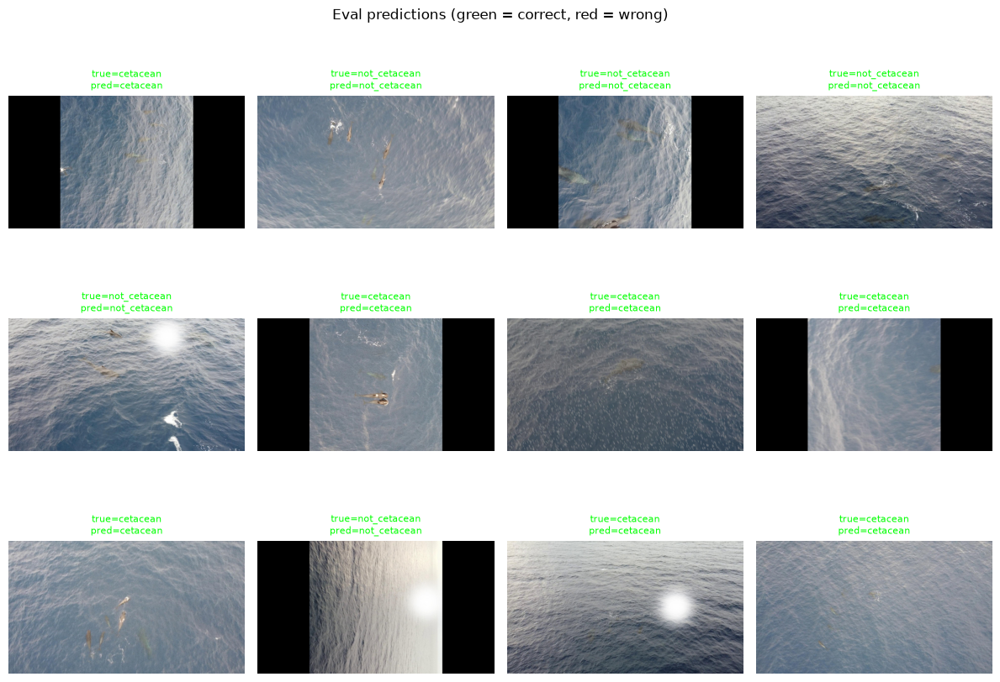

In [10]:
# --- Cell 10: Visual sample of eval predictions ---

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

N_SHOW = 12
sample_rows = random.sample(eval_rows, min(N_SHOW, len(eval_rows)))
n_cols = 4
n_rows = (len(sample_rows) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

for ax, row in zip(axes, sample_rows):
    img_path = next(r["path"] for r in records if r["path"].name == row["filename"])
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    x = np.array([[row[c] for c in cols]], dtype=float)
    pred = final_model.predict(x)[0]
    color = "lime" if pred == row["label"] else "red"
    ax.set_title(f"true={row["label"]}\npred={pred}", fontsize=8, color=color)
    ax.axis("off")
for ax in axes[len(sample_rows):]:
    ax.axis("off")

plt.suptitle("Eval predictions (green = correct, red = wrong)")
plt.tight_layout()
plt.show()

## Group-level accuracy, and seeing the actual predictions

**Why this is needed:** one real source photo was duplicated 11 times in this dataset. Row-level
accuracy (cell 9) weights that photo 11x more than a photo appearing once - the model's score on
that one duplicated photo counts 11 times over. Cell 11 below fixes this: each independent photo
group gets exactly ONE vote, regardless of how many duplicate copies exist.

Cells 12-15 show actual images: what got predicted correctly, and what got missed, for both
classes - sampled rather than showing all 6,978 eval rows.

**Requires Cell 6 to have been re-run** with the box-coordinates addition above, since drawing a
box on an image needs to know where that box actually was.

In [24]:
# --- Cell 11: Group-level accuracy - one vote per independent photo, not per row ---

from collections import defaultdict

by_group_label = defaultdict(list)
for row, pred in zip(eval_rows, y_pred):
    by_group_label[(row["group_id"], row["label"])].append(pred == row["label"])

group_majority_correct = {
    key: (sum(correct_list) / len(correct_list)) >= 0.5
    for key, correct_list in by_group_label.items()
}

print("Group-level accuracy (each independent photo counts once, however many duplicate copies it has):\n")
all_correct, all_total = 0, 0
for label in LABELS:
    keys = [k for k in group_majority_correct if k[1] == label]
    n_correct = sum(group_majority_correct[k] for k in keys)
    all_correct += n_correct
    all_total += len(keys)
    print(f"  {label:<14} {n_correct:>4} / {len(keys):<4} groups correct  ({n_correct / len(keys):.1%})")

print(f"\n  overall        {all_correct:>4} / {all_total:<4} groups correct  ({all_correct / all_total:.1%})")
print(f"\nCompare to row-level accuracy from cell 9: {(y_pred == y_eval).mean():.1%} (across {len(y_eval)} rows)")

n_multi_copy_groups = sum(1 for label in LABELS for k in by_group_label if k[1] == label and len(by_group_label[k]) > 1)
print(f"\n{n_multi_copy_groups} (group, label) combinations in eval had more than one row "
      f"(duplicate copies or multiple boxes) - these no longer get extra weight in the score above.")

Group-level accuracy (each independent photo counts once, however many duplicate copies it has):

  cetacean        209 / 238  groups correct  (87.8%)
  not_cetacean    588 / 591  groups correct  (99.5%)

  overall         797 / 829  groups correct  (96.1%)

Compare to row-level accuracy from cell 9: 92.4% (across 7091 rows)

829 (group, label) combinations in eval had more than one row (duplicate copies or multiple boxes) - these no longer get extra weight in the score above.


In [25]:
# --- Cell 12: Shared helper for the prediction galleries ---

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

PER_FIGURE = 15
N_SHOW = 15

def select_rows(true_label, was_correct):
    return [(row, pred) for row, pred in zip(eval_rows, y_pred)
            if row["label"] == true_label and (pred == row["label"]) == was_correct]

def plot_rows(selected, title):
    if not selected:
        print(f"{title}: none found.")
        return
    sample = random.sample(selected, min(N_SHOW, len(selected)))
    n_batches = (len(sample) + PER_FIGURE - 1) // PER_FIGURE
    for b in range(n_batches):
        batch = sample[b * PER_FIGURE:(b + 1) * PER_FIGURE]
        fig, axes = plt.subplots(len(batch), 1, figsize=(5, 4 * len(batch)))
        axes = [axes] if len(batch) == 1 else axes
        for ax, (row, pred) in zip(axes, batch):
            img_path = CETACEAN_IMAGES_DIR / row["filename"]
            try:
                img = Image.open(img_path).convert("RGB")
            except Exception:
                ax.axis("off")
                continue
            ax.imshow(img)
            x0, y0, x1, y1 = row["box"]
            color = "lime" if pred == row["label"] else "red"
            ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                              fill=False, edgecolor=color, linewidth=2))
            filename_short = row["filename"][:34]
            true_label = row["label"]
            ax.set_title(f"{filename_short}\ntrue={true_label}  predicted={pred}", fontsize=8)
            ax.axis("off")
        plt.suptitle(f"{title} (batch {b + 1}/{n_batches}, showing {len(sample)} of {len(selected)} total)")
        plt.tight_layout()
        plt.show()


# ===================== v7: one panel per PHOTO, every box drawn =====================
from collections import defaultdict, Counter
from matplotlib.lines import Line2D

N_PHOTOS_SHOWN = 12       # photos shown per gallery cell
PHOTOS_PER_FIGURE = 8     # photos per figure (2 columns x 4 rows)

record_by_name = {r["path"].name: r for r in records}
group_size_of = Counter(group_id_of.values())      # how many files share each photo group

photo_rows = defaultdict(list)                     # filename -> [(row, prediction), ...]
for row, pred in zip(eval_rows, y_pred):
    photo_rows[row["filename"]].append((row, pred))


def summarize_photo(items):
    animals = [(r, p) for r, p in items if r["label"] == "cetacean"]
    patches = [(r, p) for r, p in items if r["label"] == "not_cetacean"]
    return {
        "n_animals": len(animals),
        "n_caught": sum(1 for r, p in animals if p == "cetacean"),
        "n_patches": len(patches),
        "n_flagged": sum(1 for r, p in patches if p == "cetacean"),
        "group_id": items[0][0]["group_id"],
    }


photo_summary = {fname: summarize_photo(items) for fname, items in photo_rows.items()}

COLOR_CAUGHT = "#1FA37A"
COLOR_MISSED = "#F96167"
COLOR_CLEAR = "#2F6FDE"
COLOR_FALSE_ALARM = "#F59E0B"


def draw_photo(ax, fname):
    s = photo_summary[fname]
    ax.imshow(Image.open(CETACEAN_IMAGES_DIR / fname).convert("RGB"))
    for row, pred in photo_rows[fname]:
        x0, y0, x1, y1 = row["box"]
        if row["label"] == "cetacean":
            color = COLOR_CAUGHT if pred == "cetacean" else COLOR_MISSED
            style, width = "-", 2.6
        else:
            color = COLOR_FALSE_ALARM if pred == "cetacean" else COLOR_CLEAR
            style, width = "--", 1.6
        ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                                          edgecolor=color, linewidth=width, linestyle=style))
    rec = record_by_name[fname]
    cx0, cy0, cx1, cy1 = rec.get("content", (0, 0, rec["img_w"], rec["img_h"]))
    ax.set_xlim(cx0, cx1)
    ax.set_ylim(cy1, cy0)
    ax.axis("off")
    copies = group_size_of[s["group_id"]]
    line1 = f"{fname[:28]}   (copies of this photo: {copies})"
    line2 = f"animals caught {s['n_caught']}/{s['n_animals']}   |   water patches flagged {s['n_flagged']}/{s['n_patches']}"
    ax.set_title(line1 + "\n" + line2, fontsize=8)


LEGEND_HANDLES = [
    Line2D([0], [0], color=COLOR_CAUGHT, lw=2.6, label="animal caught"),
    Line2D([0], [0], color=COLOR_MISSED, lw=2.6, label="animal missed"),
    Line2D([0], [0], color=COLOR_CLEAR, lw=1.6, ls="--", label="water patch, correctly cleared"),
    Line2D([0], [0], color=COLOR_FALSE_ALARM, lw=1.6, ls="--", label="water patch wrongly flagged"),
]


def photos_where(predicate):
    return [f for f, s in photo_summary.items() if predicate(s)]


def plot_photo_gallery(filenames, title, n_show=N_PHOTOS_SHOWN):
    if not filenames:
        print(f"{title}: none found.")
        return
    sample = random.sample(filenames, min(n_show, len(filenames)))
    print(f"{title}: showing {len(sample)} of {len(filenames)} photos")
    for start in range(0, len(sample), PHOTOS_PER_FIGURE):
        batch = sample[start:start + PHOTOS_PER_FIGURE]
        n_rows = (len(batch) + 1) // 2
        fig, axes = plt.subplots(n_rows, 2, figsize=(12, 3.5 * n_rows))
        axes = np.atleast_1d(axes).ravel()
        for ax, fname in zip(axes, batch):
            draw_photo(ax, fname)
        for ax in axes[len(batch):]:
            ax.axis("off")
        fig.suptitle(title, y=1.0, fontsize=11)
        fig.legend(handles=LEGEND_HANDLES, loc="upper center", ncol=4, fontsize=8,
                   bbox_to_anchor=(0.5, 0.985), frameon=False)
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.show()


print(f"Gallery helper ready. {len(photo_summary)} eval photos (files) in {len(set(s['group_id'] for s in photo_summary.values()))} independent photo groups.")

Gallery helper ready. 1513 eval photos (files) in 591 independent photo groups.


FINAL RESULT - photos in the held-out eval set
                                                      files (1513)  independent photos (591)
Correctly classified                                  1222 (80.8%)               493 (83.4%)
Not correct: missed at least one animal                154 (10.2%)                95 (16.1%)
Not correct: false alarm on a water patch only          101 (6.7%)                  3 (0.5%)
Not correct: both                                        36 (2.4%)                  0 (0.0%)
--------------------------------------------------------------------------------------------
CORRECT / NOT CORRECT                                   1222 / 291                  493 / 98

Animal-only view (ignores the random water patches in photos that contain cetaceans):
  photos containing cetaceans: 1160
    every animal caught:        970 (83.6%)
    some caught, some missed:   87 (7.5%)
    no animal caught:           103 (8.9%)
  photos with no cetacean: 353  ->  left clean: 30

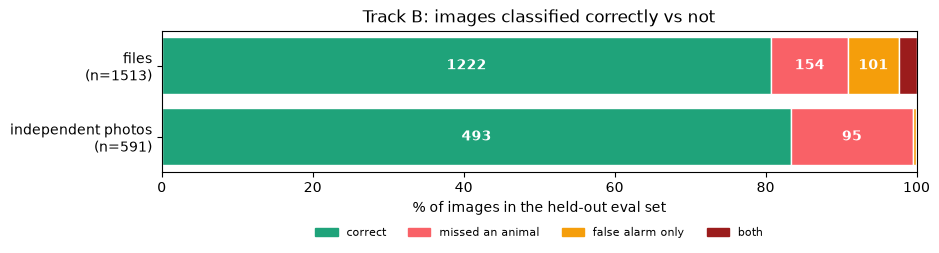

In [26]:
# --- FINAL OUTPUT: how many images were classified correctly, and how many were not ---
# An image is CORRECT only if every animal in it was caught AND none of its random water patches was wrongly
# flagged as a cetacean. Counted per file, and per independent photo (copies of one photo merged into one).

from collections import Counter, defaultdict
import matplotlib.pyplot as plt


def status(missed, flagged):
    if missed and flagged:
        return "both"
    if missed:
        return "missed"
    if flagged:
        return "false_alarm"
    return "correct"


def file_status(s):
    return status(s["n_caught"] < s["n_animals"], s["n_flagged"] > 0)


file_counts = Counter(file_status(s) for s in photo_summary.values())
n_files = len(photo_summary)

# per independent photo (all copies merged). Animals: EVERY animal box must be caught, in every copy (strict, same as the
# file column). Water patches: a majority must be cleared - a photo with many copies has many random patches, so a strict
# rule there would unfairly punish heavily duplicated photos.
by_group_label = defaultdict(list)
for row, pred in zip(eval_rows, y_pred):
    by_group_label[(row["group_id"], row["label"])].append(pred == row["label"])
all_groups = sorted({gid for gid, _ in by_group_label})


def group_status(gid):
    animals = by_group_label.get((gid, "cetacean"))
    patches = by_group_label.get((gid, "not_cetacean"))
    missed = animals is not None and not all(animals)
    flagged = patches is not None and (sum(patches) / len(patches)) < 0.5
    return status(missed, flagged)


group_counts = Counter(group_status(g) for g in all_groups)
n_groups = len(all_groups)


def pct(k, n):
    return f"{100 * k / n:.1f}%" if n else "n/a"


rows_for_table = [
    ("correct", "Correctly classified"),
    ("missed", "Not correct: missed at least one animal"),
    ("false_alarm", "Not correct: false alarm on a water patch only"),
    ("both", "Not correct: both"),
]
print("=" * 92)
print("FINAL RESULT - photos in the held-out eval set")
print("=" * 92)
print(f"{'':<50}{'files (' + str(n_files) + ')':>16}{'independent photos (' + str(n_groups) + ')':>26}")
for key, text in rows_for_table:
    f_txt = f"{file_counts[key]} ({pct(file_counts[key], n_files)})"
    g_txt = f"{group_counts[key]} ({pct(group_counts[key], n_groups)})"
    print(f"{text:<50}{f_txt:>16}{g_txt:>26}")
n_ok_f, n_ok_g = file_counts["correct"], group_counts["correct"]
print("-" * 92)
print(f"{'CORRECT / NOT CORRECT':<50}{str(n_ok_f) + ' / ' + str(n_files - n_ok_f):>16}{str(n_ok_g) + ' / ' + str(n_groups - n_ok_g):>26}")

with_animals = [s for s in photo_summary.values() if s["n_animals"] > 0]
all_caught = sum(1 for s in with_animals if s["n_caught"] == s["n_animals"])
none_caught = sum(1 for s in with_animals if s["n_caught"] == 0)
partly = len(with_animals) - all_caught - none_caught
no_animals = [s for s in photo_summary.values() if s["n_animals"] == 0]
no_animals_flagged = sum(1 for s in no_animals if s["n_flagged"] > 0)

print("\nAnimal-only view (ignores the random water patches in photos that contain cetaceans):")
print(f"  photos containing cetaceans: {len(with_animals)}")
print(f"    every animal caught:        {all_caught} ({pct(all_caught, len(with_animals))})")
print(f"    some caught, some missed:   {partly} ({pct(partly, len(with_animals))})")
print(f"    no animal caught:           {none_caught} ({pct(none_caught, len(with_animals))})")
print(f"  photos with no cetacean: {len(no_animals)}  ->  left clean: {len(no_animals) - no_animals_flagged}, "
      f"wrongly flagged: {no_animals_flagged}")

n_boxes = len(eval_rows)
n_boxes_ok = sum(1 for r, p in zip(eval_rows, y_pred) if p == r["label"])
print(f"\nFor reference, box level (cell 9): {n_boxes_ok} of {n_boxes} boxes right ({pct(n_boxes_ok, n_boxes)})")

colors = {"correct": "#1FA37A", "missed": "#F96167", "false_alarm": "#F59E0B", "both": "#9B1C1C"}
names = {"correct": "correct", "missed": "missed an animal", "false_alarm": "false alarm only", "both": "both"}
fig, ax = plt.subplots(figsize=(9.5, 2.9))
for y, (label, counts, total) in enumerate([("independent photos", group_counts, n_groups), ("files", file_counts, n_files)]):
    left = 0.0
    for key in ["correct", "missed", "false_alarm", "both"]:
        width = 100 * counts[key] / total if total else 0
        ax.barh(y, width, left=left, color=colors[key], edgecolor="white")
        if width >= 5:
            ax.text(left + width / 2, y, str(counts[key]), ha="center", va="center", color="white", fontsize=10, fontweight="bold")
        left += width
ax.set_yticks([0, 1])
ax.set_yticklabels([f"independent photos\n(n={n_groups})", f"files\n(n={n_files})"])
ax.set_xlim(0, 100)
ax.set_xlabel("% of images in the held-out eval set")
ax.set_title("Track B: images classified correctly vs not")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=colors[k]) for k in colors], labels=[names[k] for k in colors],
          loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=4, frameon=False, fontsize=8)
plt.tight_layout()
fig.savefig("trackb_final_result.png", dpi=150, bbox_inches="tight")
print("\nChart saved as trackb_final_result.png (in the folder this notebook runs from)")
plt.show()

Every animal in the photo was caught: showing 12 of 970 photos


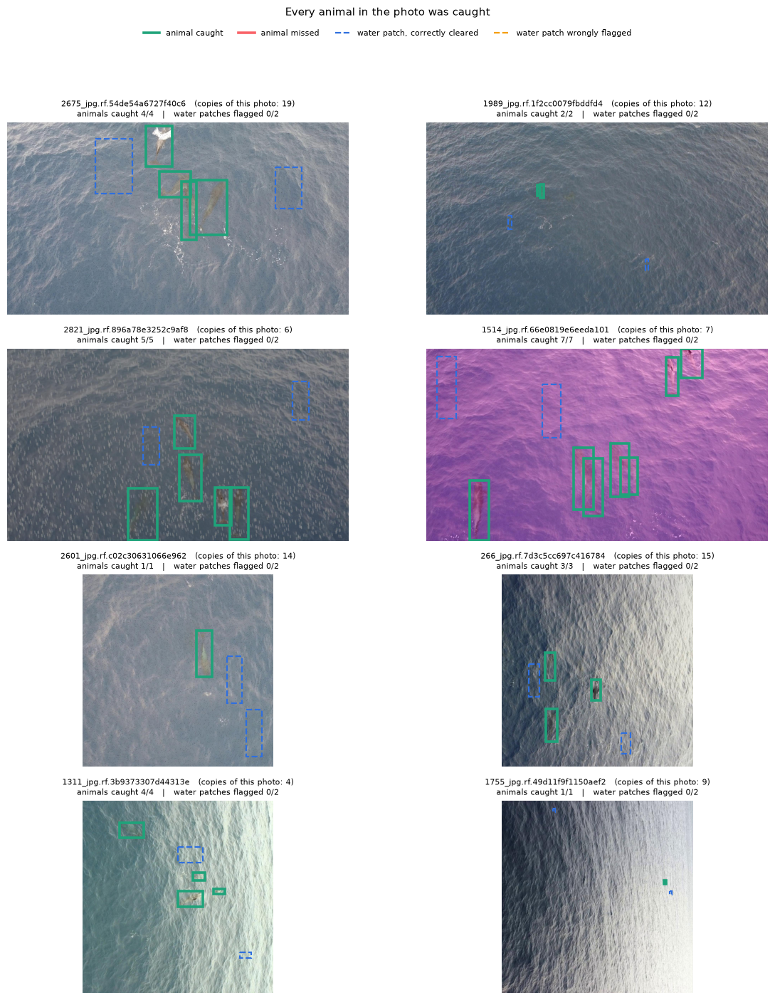

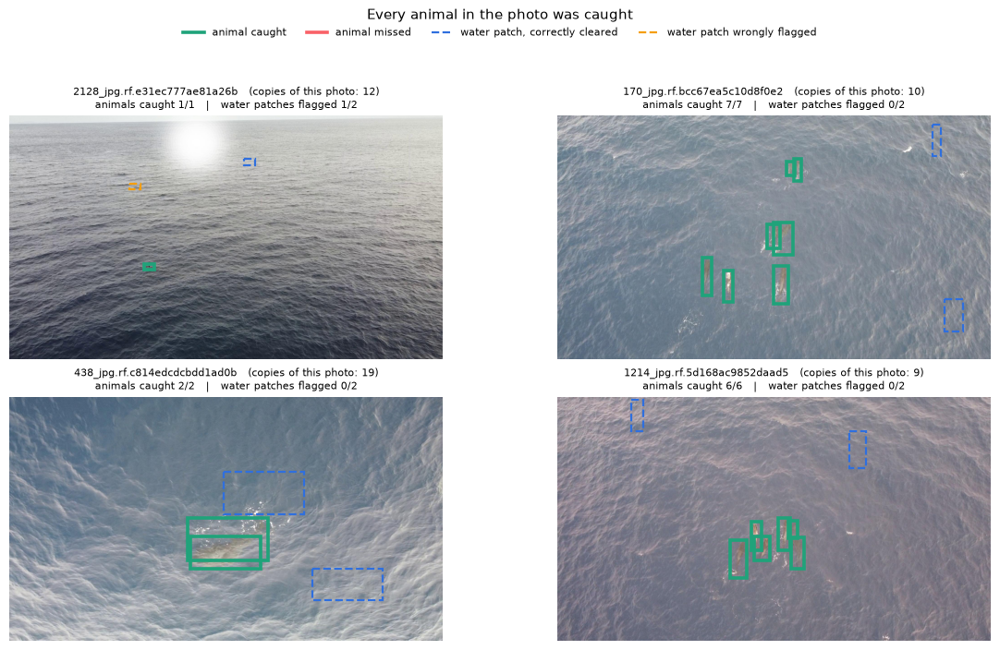

In [27]:
# --- Photos where EVERY animal was caught ---
plot_photo_gallery(photos_where(lambda s: s["n_animals"] > 0 and s["n_caught"] == s["n_animals"]),
                   "Every animal in the photo was caught")

Some animals caught, some missed: showing 12 of 87 photos


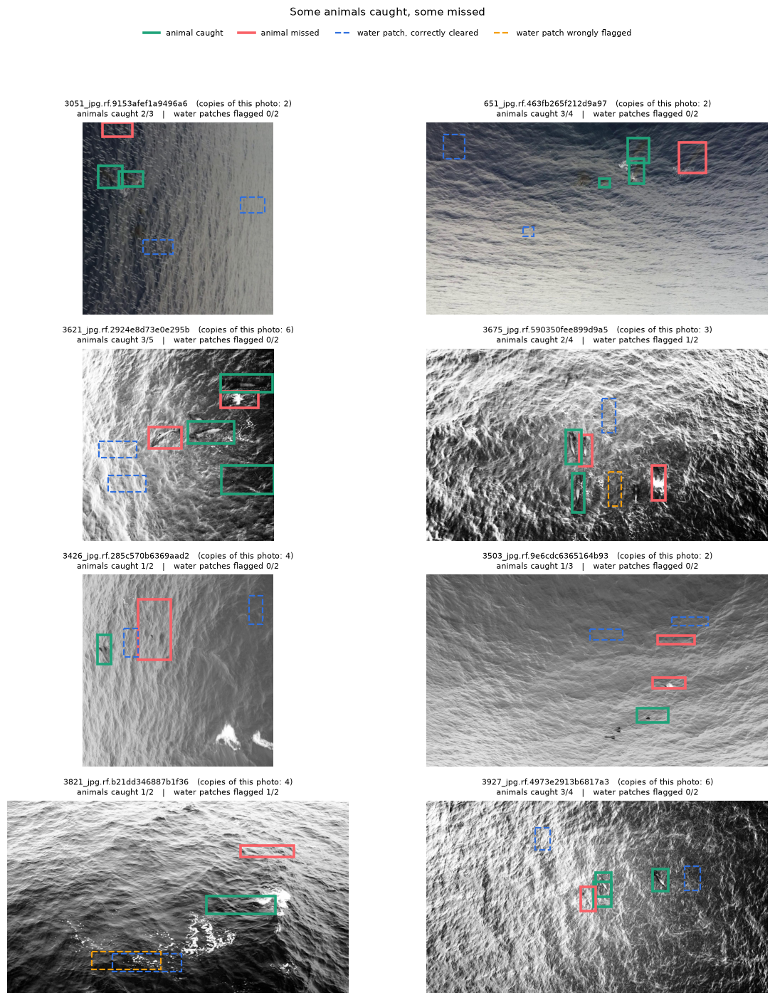

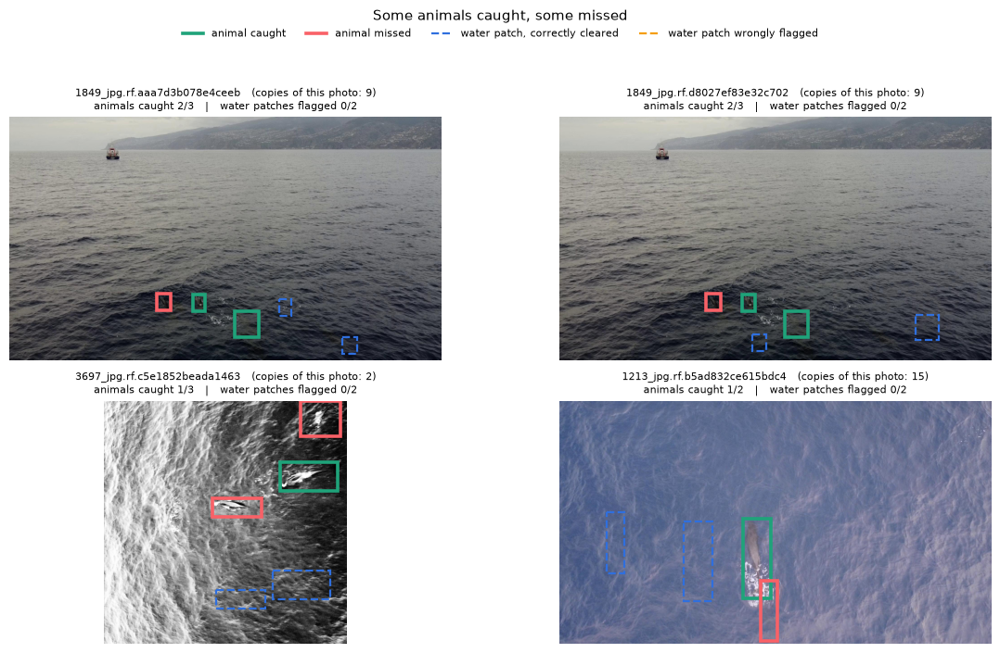

In [28]:
# --- Photos where SOME animals were caught and some missed ---
plot_photo_gallery(photos_where(lambda s: 0 < s["n_caught"] < s["n_animals"]),
                   "Some animals caught, some missed")

No animal in the photo was caught: showing 12 of 103 photos


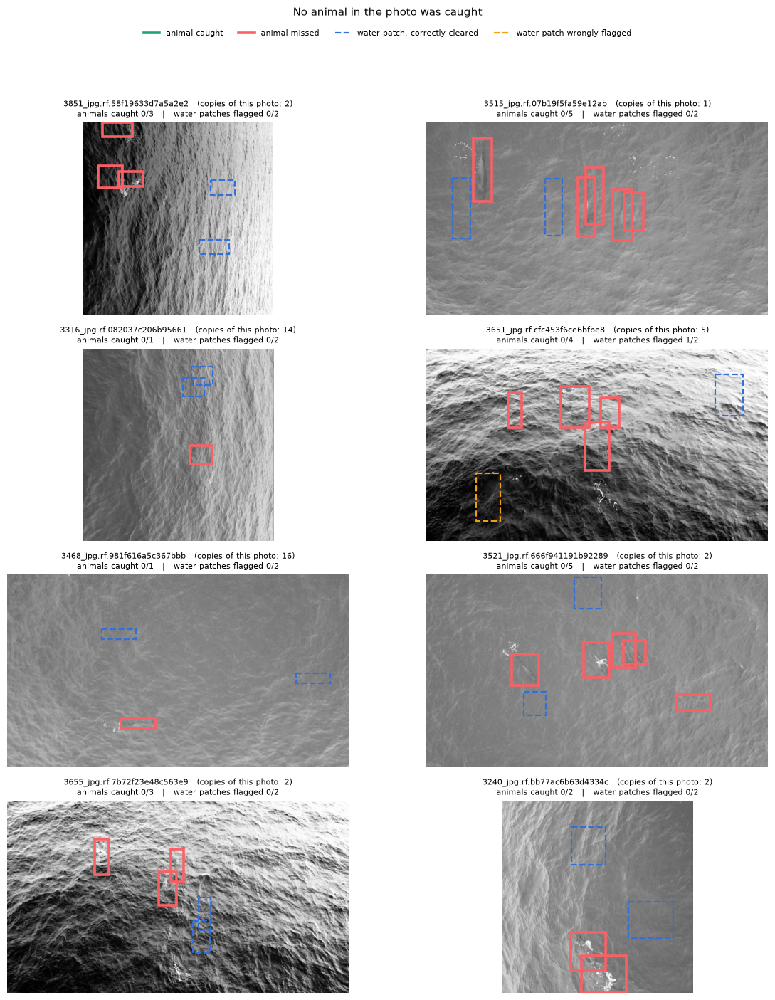

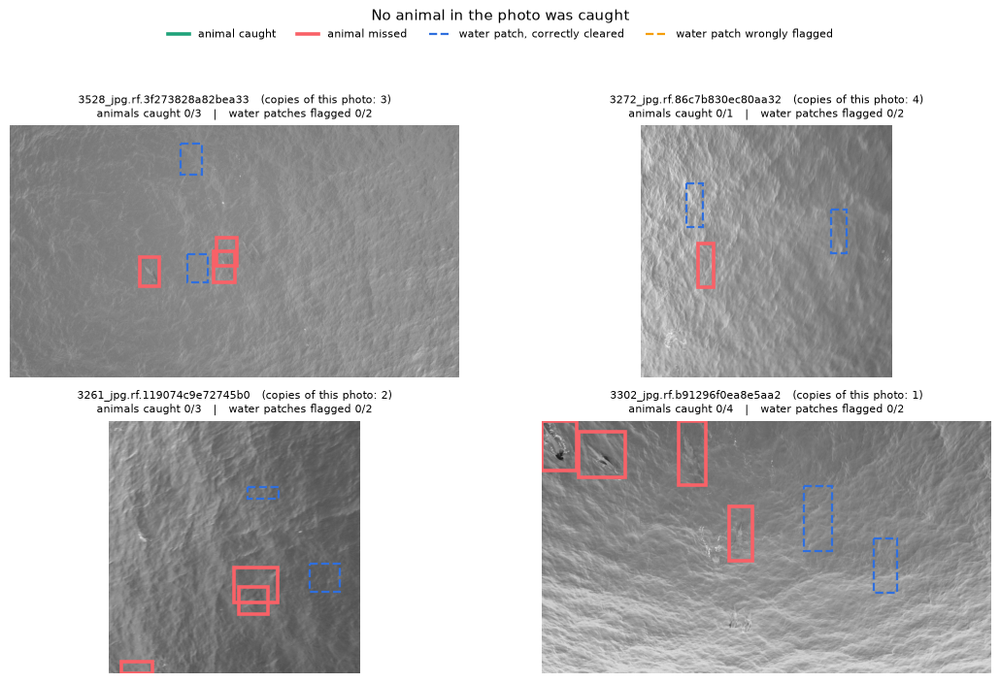

In [29]:
# --- Photos where NO animal was caught ---
plot_photo_gallery(photos_where(lambda s: s["n_animals"] > 0 and s["n_caught"] == 0),
                   "No animal in the photo was caught")

A water patch was wrongly flagged as cetacean: showing 12 of 137 photos


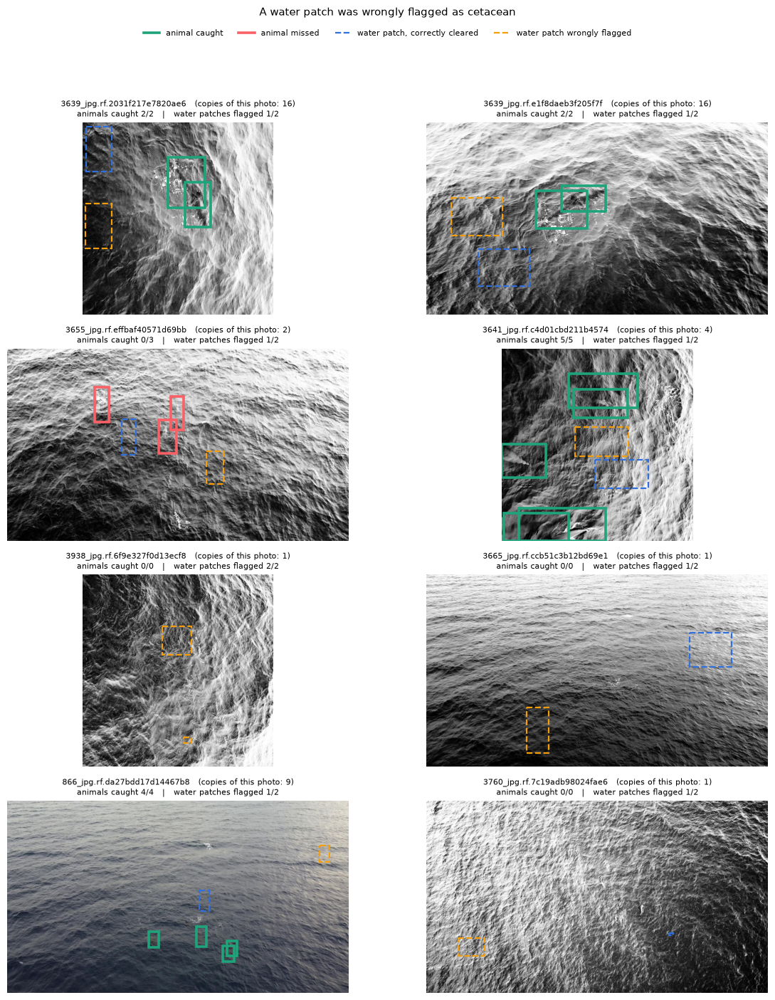

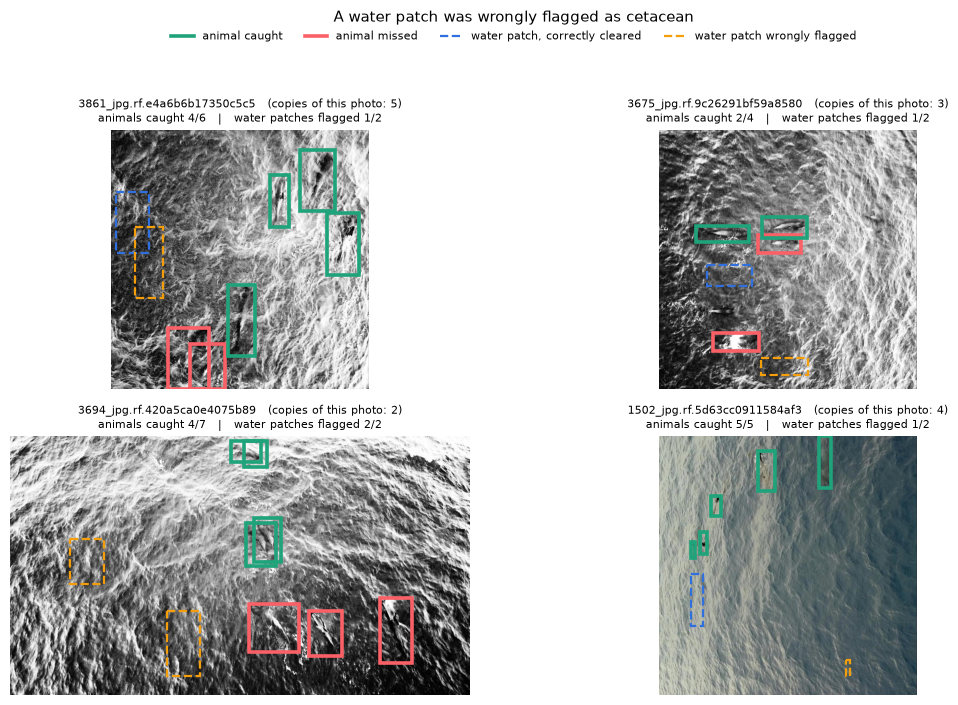

In [30]:
# --- Photos where a water patch was wrongly flagged as a cetacean ---
plot_photo_gallery(photos_where(lambda s: s["n_flagged"] > 0),
                   "A water patch was wrongly flagged as cetacean")

## Testing the hypothesis: are missed cetaceans mostly never-duplicated sightings?

Before changing anything, this checks directly: does a cetacean sighting's duplicate-group
size (how many times that same photo was saved) predict whether the model gets it right?
If missed sightings cluster at group size 1 (never duplicated), that confirms the theory that
easy, duplicated sightings were inflating the row-level score - and it points at the real
weak spot: rare, one-off sightings specifically, not cetacean detection in general.


Correctly predicted cetacean (n=3679):
  mean group size:   7.21
  median group size: 6
  never-duplicated (group size 1): 102 (2.8%)

Missed cetacean (n=386):
  mean group size:   4.59
  median group size: 3
  never-duplicated (group size 1): 33 (8.5%)

CONFIRMED DIRECTION: missed sightings have smaller duplicate groups on average than
correct ones - consistent with "easy sightings got duplicated more, propping up the
row-level score". The real weak spot is rare, never-duplicated sightings specifically.


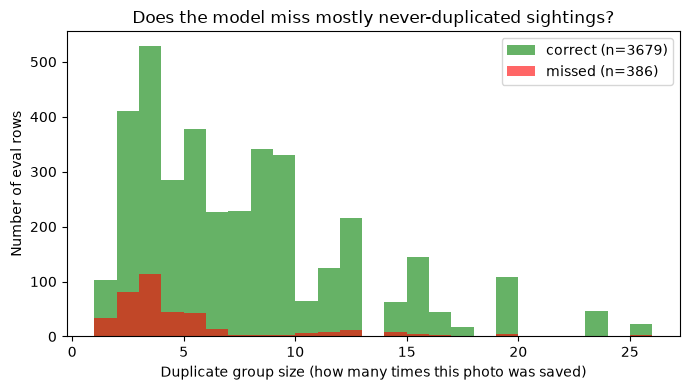

In [18]:
# --- Group-size diagnostic: numeric test of the hypothesis ---

from collections import Counter
import numpy as np

group_size_of = Counter(group_id_of.values())  # group_id -> how many duplicate images share it

correct_pairs = select_rows("cetacean", was_correct=True)
missed_pairs = select_rows("cetacean", was_correct=False)

correct_sizes = [group_size_of[row["group_id"]] for row, pred in correct_pairs]
missed_sizes = [group_size_of[row["group_id"]] for row, pred in missed_pairs]

def summarize(sizes, label):
    n_singleton = sum(1 for s in sizes if s == 1)
    print(f"{label} (n={len(sizes)}):")
    print(f"  mean group size:   {np.mean(sizes):.2f}")
    print(f"  median group size: {np.median(sizes):.0f}")
    print(f"  never-duplicated (group size 1): {n_singleton} ({n_singleton / len(sizes):.1%})")

summarize(correct_sizes, "Correctly predicted cetacean")
print()
summarize(missed_sizes, "Missed cetacean")

print()
if np.mean(missed_sizes) < np.mean(correct_sizes):
    print("CONFIRMED DIRECTION: missed sightings have smaller duplicate groups on average than")
    print("correct ones - consistent with \"easy sightings got duplicated more, propping up the")
    print("row-level score\". The real weak spot is rare, never-duplicated sightings specifically.")
else:
    print("NOT CONFIRMED: missed sightings do not have smaller duplicate groups on average.")
    print("The weakness looks more evenly spread - likely a genuine feature-set limitation")
    print("rather than a quirk of which sightings happened to be duplicated more.")

fig, ax = plt.subplots(figsize=(7, 4))
max_size = max(max(correct_sizes), max(missed_sizes))
bins = range(1, max_size + 2)
ax.hist(correct_sizes, bins=bins, alpha=0.6, label=f"correct (n={len(correct_sizes)})", color="green")
ax.hist(missed_sizes, bins=bins, alpha=0.6, label=f"missed (n={len(missed_sizes)})", color="red")
ax.set_xlabel("Duplicate group size (how many times this photo was saved)")
ax.set_ylabel("Number of eval rows")
ax.set_title("Does the model miss mostly never-duplicated sightings?")
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
# --- Gallery sorted by group size, so the hardest (least-duplicated) cases show first ---

def plot_rows_sorted_by_group_size(selected, title, ascending=True):
    if not selected:
        print(f"{title}: none found.")
        return
    selected_sorted = sorted(selected, key=lambda rp: group_size_of[rp[0]["group_id"]], reverse=not ascending)
    sample = selected_sorted[:N_SHOW]
    n_batches = (len(sample) + PER_FIGURE - 1) // PER_FIGURE
    for b in range(n_batches):
        batch = sample[b * PER_FIGURE:(b + 1) * PER_FIGURE]
        fig, axes = plt.subplots(len(batch), 1, figsize=(5, 4 * len(batch)))
        axes = [axes] if len(batch) == 1 else axes
        for ax, (row, pred) in zip(axes, batch):
            img_path = CETACEAN_IMAGES_DIR / row["filename"]
            try:
                img = Image.open(img_path).convert("RGB")
            except Exception:
                ax.axis("off")
                continue
            ax.imshow(img)
            x0, y0, x1, y1 = row["box"]
            color = "lime" if pred == row["label"] else "red"
            ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                              fill=False, edgecolor=color, linewidth=2))
            group_size = group_size_of[row["group_id"]]
            filename_short = row["filename"][:30]
            true_label = row["label"]
            ax.set_title(f"{filename_short}\ngroup_size={group_size}  true={true_label}  predicted={pred}", fontsize=8)
            ax.axis("off")
        order_word = "smallest" if ascending else "largest"
        plt.suptitle(f"{title} - sorted {order_word} group first (batch {b + 1}/{n_batches})")
        plt.tight_layout()
        plt.show()

print("Sorted gallery helper ready.")


Sorted gallery helper ready.


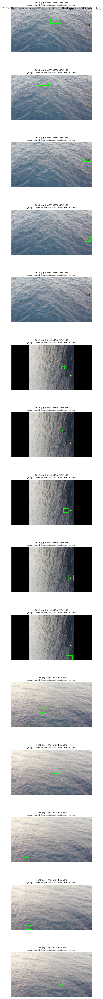

In [22]:
# --- Correctly predicted cetacean, hardest (smallest group) first ---
plot_rows_sorted_by_group_size(select_rows("cetacean", was_correct=True),
                                 "Correctly predicted cetacean", ascending=True)

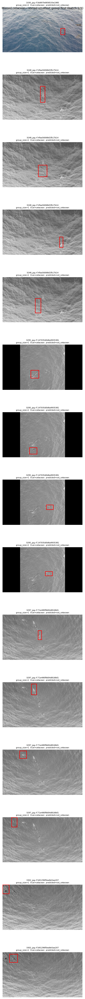

In [23]:
# --- Missed cetacean, hardest (smallest group) first ---
plot_rows_sorted_by_group_size(select_rows("cetacean", was_correct=False),
                                 "Missed cetacean", ascending=True)
